# Correlators of longitudinal and transverse electric and magnetic fields of the Glasma

Computation of gauge invariant correlators of chromoelectric and chromomagnetic fields. The longitudinal correlation is $\langle FF\rangle_L(r) = \langle \mathrm{Tr} \left\{ F_z(x_T) U_{x \rightarrow y} F_z(y_T) U_{y \rightarrow x} \right\} \rangle$ with $r\equiv x_T-y_T$ and $F\in\{E,B\}$ either the electric or magnetic field, whereas the transvrse one is evaluated as $\langle FF\rangle_{T}(r) = \langle \mathrm{Tr} \left\{ F_x(x_T) U_{x \rightarrow y} F_x(y_T) U_{y \rightarrow x} \right\} \rangle+\langle \mathrm{Tr} \left\{ F_y(x_T) U_{x \rightarrow y} F_y(y_T) U_{y \rightarrow x} \right\} \rangle$.

In [12]:
# Set environment variables 
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["GAUGE_GROUP"] = "su3"
os.environ["PRECISION"] = "double"

# Import curraun and other packages
import sys
sys.path.append('../..')

import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False
from curraun.correlators import Correlators
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rc
rc('text', usetex=True)
plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams.update({'font.size':18})

import pickle
from tqdm import tqdm

from curraun.numba_target import use_cuda, use_numba
if use_cuda:
    from numba import cuda

Using CUDA
Using SU(3)
Using double precision
Using double precision


In [13]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326

# Simulation box
L   = 10.0
N   = 1024
DTS = 8
NE  = 5

# Glasma fields
g2mu = 2.0          # g²μ [GeV]
g    = 2.0          # coupling constant
mu   = g2mu / g**2  # MV model parameter [GeV]
ir   = 0.2          # infrared regulator [GeV]
uv   = 10.0         # ultraviolet regulator [GeV]
NS   = 50           # number of color charge sheets

# Derived lattice parameters
a  = L / N
E0 = N / L * hbarc
DT = 1.0 / DTS

# Dimensionless times g²μ·τ at which correlators are saved
g2mu_taus = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0]
taus = [x / g2mu * hbarc for x in g2mu_taus]        # proper time [fm/c]
ts   = np.round([tau * N / L * DTS for tau in taus]).astype(int)

# Validity checks
cond1_lhs = 2 * np.pi / L * hbarc
print(f"2π/L  = {cond1_lhs:.4f} < m    = {ir}   {'passed' if cond1_lhs < ir  else 'FAILED'}")

cond2_lhs = ir / g2mu
print(f"m/g²μ = {cond2_lhs:.4f} < 1           {'passed' if cond2_lhs < 1   else 'FAILED'}")

cond3_lhs = g2mu * a / hbarc
print(f"g²μ·a = {cond3_lhs:.4f} < 1           {'passed' if cond3_lhs < 1   else 'FAILED'}")

print(f"g²μ·L = {g2mu * L / hbarc:.4f}")
print(f"Lattice steps at saved times: {ts}")


2π/L  = 0.1240 < m    = 0.2   passed
m/g²μ = 0.1000 < 1           passed
g²μ·a = 0.0990 < 1           passed
g²μ·L = 101.3551
Lattice steps at saved times: [  8  16  40  81 121 162]


In [ ]:
# Empty dictionaries of correlators
ETs, BTs = {}, {}
ELs, BLs = {}, {}

for t in ts:
    ETs[str(int(t))], BTs[str(int(t))] = [], []
    ELs[str(int(t))], BLs[str(int(t))] = [], []

ts_set = set(ts.tolist())   # O(1) membership lookup

with tqdm(total=NE) as pbar:
    for e in range(NE):
        s  = core.Simulation(N, DT, g)
        va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=NS)
        vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=NS)
        initial.init(s, va, vb)

        if use_cuda:
            s.copy_to_device()

        for t in range(int(ts[-1]) + 1):
            core.evolve_leapfrog(s)

            if t in ts_set:
                corr = Correlators(s)
                corr.compute('Ex'); Ex_c = corr.corr.copy()
                corr.compute('Ey'); Ey_c = corr.corr.copy()
                ETs[str(int(t))].append(Ex_c + Ey_c)

                corr.compute('Bx'); Bx_c = corr.corr.copy()
                corr.compute('By'); By_c = corr.corr.copy()
                BTs[str(int(t))].append(Bx_c + By_c)

                corr.compute('Ez'); Ez_c = corr.corr.copy()
                ELs[str(int(t))].append(Ez_c)

                corr.compute('Bz'); Bz_c = corr.corr.copy()
                BLs[str(int(t))].append(Bz_c)

        pbar.set_description(f'Event {e+1} of {NE}')
        pbar.update(1)

ET_avg, BT_avg = {}, {}
EL_avg, BL_avg = {}, {}

for t in ts:
    ET_avg[str(int(t))] = np.mean(np.array(ETs[str(int(t))]), axis=0)
    BT_avg[str(int(t))] = np.mean(np.array(BTs[str(int(t))]), axis=0)
    EL_avg[str(int(t))] = np.mean(np.array(ELs[str(int(t))]), axis=0)
    BL_avg[str(int(t))] = np.mean(np.array(BLs[str(int(t))]), axis=0)

res = {}
res["ET"], res["BT"] = ET_avg, BT_avg
res["EL"], res["BL"] = EL_avg, BL_avg
res["ts"], res["taus"] = ts, taus
res["g2mu_taus"] = g2mu_taus

r = np.linspace(0, L / 2, num=N // 2)
res["r"] = r
res["g2mu"], res["g"] = g2mu, g
res["E0"], res["hbarc"] = E0, hbarc

fname = "trans_long_corr_spatial.pickle"
pickle.dump(res, open(fname, "wb"))


Event 5 of 5: 100%|██████████| 5/5 [16:04<00:00, 192.91s/it]


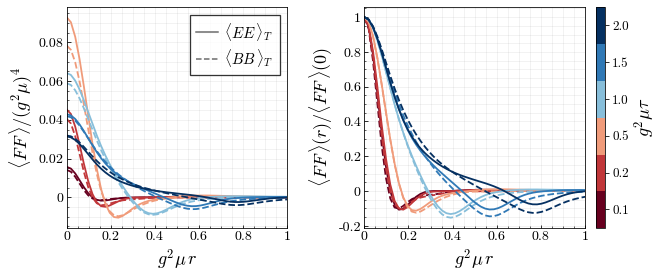

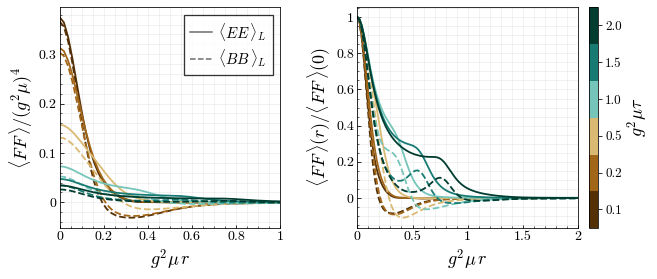

In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

# Load results
fname = "trans_long_corr_spatial.pickle"
res = pickle.load(open(fname, "rb"))

r         = res["r"]
g2mu      = res["g2mu"]
g         = res["g"]
E0        = res["E0"]
ts        = res["ts"]
g2mu_taus = res["g2mu_taus"]
ET_avg    = res["ET"]
BT_avg    = res["BT"]
EL_avg    = res["EL"]
BL_avg    = res["BL"]

units = E0**4 / g**2
n = len(ts)
tau_labels = [str(x) for x in g2mu_taus]


def _make_colors(cmap_name, n, skip_inner=2):
    """Sample n+skip_inner colors from the diverging cmap, drop the skip_inner
    innermost (brightest) ones, leaving n colors from the dark outer regions."""
    n_total = n + skip_inner
    cmap_d  = cm.get_cmap(cmap_name, n_total)
    all_c   = [cmap_d(i) for i in range(n_total)]
    half    = n_total // 2
    return all_c[: half - skip_inner // 2] + all_c[half + skip_inner // 2 :]


def _fmt_ax(ax, xlabel=None, ylabel=None, xlims=None, ylims=None, fontsize=14):
    if xlims:
        ax.set_xlim(*xlims)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.set_box_aspect(1)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize + 4)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize + 4)


def _make_fig(cmap_name, plot_fn_abs, plot_fn_norm, cbar_label):
    colors = _make_colors(cmap_name, n)

    fig, (ax_abs, ax_norm) = plt.subplots(1, 2, figsize=(10, 4.5))
    fig.subplots_adjust(left=0.10, right=0.82, bottom=0.14, top=0.95, wspace=0.35)

    plot_fn_abs(ax_abs, colors)
    plot_fn_norm(ax_norm, colors)

    leg = ax_abs.legend(handles=[
        Line2D([0], [0], color='dimgray', linewidth=1.5, linestyle='-',
               label=plot_fn_norm._ee_label),
        Line2D([0], [0], color='dimgray', linewidth=1.5, linestyle='--',
               label=plot_fn_norm._bb_label),
    ], fontsize=15, frameon=True, loc='upper right',
       facecolor='white', edgecolor='black',
       handlelength=1.5, borderpad=0.4, shadow=False,
       handletextpad=0.4, labelspacing=0.3)
    frame = leg.get_frame()
    frame.set_linewidth(1.3)
    frame.set_boxstyle('square', pad=0)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = ax_norm.get_window_extent(renderer).transformed(fig.transFigure.inverted())

    cbar_ax = fig.add_axes([bbox.x1 + 0.016, bbox.y0, 0.012, bbox.height])

    cmap_disc = ListedColormap(colors)
    norm_disc = BoundaryNorm(np.arange(0.5, n + 1.5), cmap_disc.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_disc, norm=norm_disc)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=18)
    cbar.set_ticks(np.arange(1, n + 1))
    cbar.set_ticklabels(tau_labels)
    cbar.ax.tick_params(labelsize=13)

    return fig


# Figure 1: Transverse correlators  
def _plot_T_abs(ax, colors):
    for i, t in enumerate(ts):
        x   = r * g2mu
        y_E = ET_avg[str(int(t))] * units / g2mu**4
        y_B = BT_avg[str(int(t))] * units / g2mu**4
        ax.plot(x, y_E, color=colors[i], linewidth=1.8)
        ax.plot(x, y_B, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\, r$', ylabel=r'$\langle FF\,\rangle/(g^2\mu)^4$',
            xlims=(0, 1))

def _plot_T_norm(ax, colors):
    for i, t in enumerate(ts):
        x   = r * g2mu
        y_E = ET_avg[str(int(t))] / ET_avg[str(int(t))][0]
        y_B = BT_avg[str(int(t))] / BT_avg[str(int(t))][0]
        ax.plot(x, y_E, color=colors[i], linewidth=1.8)
        ax.plot(x, y_B, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\, r$',
            ylabel=r'$\langle FF\,\rangle(r)/\langle FF\,\rangle(0)$',
            xlims=(0, 1))
_plot_T_norm._ee_label = r'$\langle EE\,\rangle_T$'
_plot_T_norm._bb_label = r'$\langle BB\,\rangle_T$'

fig_T = _make_fig('RdBu', _plot_T_abs, _plot_T_norm, r'$g^2\mu\tau$')
fig_T.savefig("trans_corr_spatial.pdf", bbox_inches='tight')
fig_T.savefig("trans_corr_spatial.png", bbox_inches='tight', dpi=200)
plt.show()


# Figure 2: Longitudinal correlators  
def _plot_L_abs(ax, colors):
    for i, t in enumerate(ts):
        x   = r * g2mu
        y_E = EL_avg[str(int(t))] * units / g2mu**4
        y_B = BL_avg[str(int(t))] * units / g2mu**4
        ax.plot(x, y_E, color=colors[i], linewidth=1.8)
        ax.plot(x, y_B, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\, r$', ylabel=r'$\langle FF\,\rangle/(g^2\mu)^4$',
            xlims=(0, 1))

def _plot_L_norm(ax, colors):
    for i, t in enumerate(ts):
        x   = r * g2mu
        y_E = EL_avg[str(int(t))] / EL_avg[str(int(t))][0]
        y_B = BL_avg[str(int(t))] / BL_avg[str(int(t))][0]
        ax.plot(x, y_E, color=colors[i], linewidth=1.8)
        ax.plot(x, y_B, color=colors[i], linewidth=1.8, linestyle='--')
    _fmt_ax(ax, xlabel=r'$g^2\mu\, r$',
            ylabel=r'$\langle FF\,\rangle(r)/\langle FF\,\rangle(0)$',
            xlims=(0, 2))
_plot_L_norm._ee_label = r'$\langle EE\,\rangle_L$'
_plot_L_norm._bb_label = r'$\langle BB\,\rangle_L$'

fig_L = _make_fig('BrBG', _plot_L_abs, _plot_L_norm, r'$g^2\mu\tau$')
fig_L.savefig("long_corr_spatial.pdf", bbox_inches='tight')
fig_L.savefig("long_corr_spatial.png", bbox_inches='tight', dpi=200)
plt.show()


## Read data from file using Julia

In [ ]:
using Pickle

res = Pickle.npyload("results/trans_long_correlators.pickle")

function string_as_varname(s::AbstractString,v::Any)
    s=Symbol(s)
    return @eval (($s) = ($v))
end

string_as_varname (generic function with 1 method)

## Plot transverse and longitudinal electric and magnetic fields correlators, using Makie from Julia

In [13]:
using CairoMakie
using ColorSchemes

colormap = cgrad(:starrynight, 6, categorical = true)
colors = [colormap[1], colormap[2], colormap[3], colormap[4], colormap[5], colormap[6]]

fig = Figure(resolution = (700, 400), font = "CMU Serif")
ax = Axis(fig[1,1], xlabel=L"Q_s r", ylabel=L"\langle FF\,\rangle_T\,(r)/Q_s^4",
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4,  xlabelpadding = -5, xgridvisible = false, ygridvisible = false) 

units = res["E0"]^4/res["G"]^2
for (i, t) in enumerate(res["ts"])
        string_as_varname("line_el_"*string(i), lines!(ax, res["r"].*res["Qs"], res["ET"][string(t)].*units./res["Qs"]^4, linewidth = 1.8, color=colors[i]))
        string_as_varname("line_mag_"*string(i), lines!(ax, res["r"].*res["Qs"], res["BT"][string(t)].*units./res["Qs"]^4, linestyle="-", linewidth = 1.8, color=colors[i]))
        lines!(ax, res["r"].*res["Qs"], res["BT"][string(t)].*units./res["Qs"]^4, linewidth = 1.8, color=(colors[i], 0.3))
end

xlims!(ax, 0, 1)
ylims!(ax, -0.04, 0.2)
ax.xticks = (0.25*(0:4), ["0", "0.25", "0.5", "0.75", "1"])
ax.yticks = ([0, 0.1, 0.2], ["0", "0.1", "0.2"])

cbar = Colorbar(fig[1, 2], limits = (0, 6), colormap =  colormap = cgrad(:starrynight, 6, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"\tau\,\mathrm{[fm/c]}")
cbar.ticks = ([0.5, 1.5, 2.5, 3.5, 4.5, 5.5],  ["0.01", "0.05", "0.1", "0.15", "0.3", "0.5"])

ax_inset = Axis(fig, bbox = BBox(250, 550, 170, 350), 
        xlabel=L"Q_s r", ylabel=L"\langle FF\,\rangle_T\,(r)/\langle FF\,\rangle_T\,(0)",
        xlabelsize = 16, ylabelsize= 16, xticklabelsize=12, yticklabelsize=12,
        xtickalign = 1, xticksize=3, ytickalign=1, yticksize=3, xlabelpadding = -2, xgridvisible = false, ygridvisible = false,
        ytickcolor = :grey, xtickcolor = :grey, yticklabelcolor = :grey, xticklabelcolor = :grey, ylabelcolor = :grey, xlabelcolor = :grey,
        bottomspinecolor = :grey, topspinecolor = :grey, leftspinecolor = :grey, rightspinecolor = :grey)

for (i, t) in enumerate(res["ts"])
        lines!(ax_inset, res["r"].*res["Qs"], res["ET"][string(t)]/res["ET"][string(t)][1], linewidth = 1, color=colors[i])
        lines!(ax_inset, res["r"].*res["Qs"], res["BT"][string(t)]/res["BT"][string(t)][1], linestyle="-", linewidth = 1, color=colors[i])
        lines!(ax_inset, res["r"].*res["Qs"], res["BT"][string(t)]/res["BT"][string(t)][1], linewidth = 1, color=(colors[i], 0.3))
end

xlims!(ax_inset, 0, 1)
ylims!(ax_inset, -0.2, 1)
ax_inset.xticks = (0.25*(0:4), ["0", "0.25", "0.5", "0.75", "1"])
ax_inset.yticks = ([0, 0.5, 1], ["0", "0.5", "1"])

mag = [LineElement(color = colors[1], linestyle = "-", linewidth = 1.5), LineElement(color = (colors[1], 0.4), linewidth = 1.5)]

axislegend(ax_inset, [line_el_1, mag], [L"\langle EE\,\rangle_T", L"\langle BB\,\rangle_T"],  labelsize=18, 
    position = :rt, bgcolor = (:white, 0.7), framecolor = (:white, 0))

display(fig)

# save("plots/corr_FF_T.png", fig, px_per_unit = 5.0) 

SyntaxError: invalid syntax (<ipython-input-13-bbc566ae36b3>, line 1)

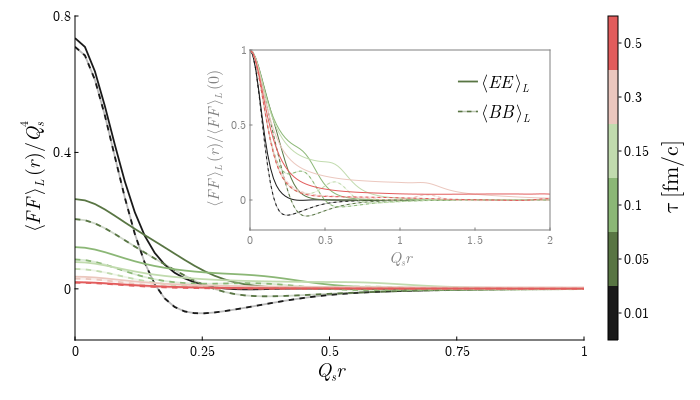

In [ ]:
using CairoMakie
using Interpolations
using ColorSchemes

colormap = cgrad(:watermelon, 6, categorical = true)
colors = [colormap[1], colormap[2], colormap[3], colormap[4], colormap[5], colormap[6]]

fig = Figure(resolution = (700, 400), font = "CMU Serif")
ax = Axis(fig[1,1], xlabel=L"Q_s r", ylabel=L"\langle FF\,\rangle_L\,(r)/Q_s^4",
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4,  xlabelpadding = -5, xgridvisible = false, ygridvisible = false) 

units = res["E0"]^4/res["G"]^2
for (i, t) in enumerate(res["ts"])
        string_as_varname("line_el_"*string(i), lines!(ax, res["r"].*res["Qs"], res["EL"][string(t)].*units./res["Qs"]^4, linewidth = 1.8, color=colors[i]))
        string_as_varname("line_mag_"*string(i), lines!(ax, res["r"].*res["Qs"], res["BL"][string(t)].*units./res["Qs"]^4, linestyle="-", linewidth = 1.8, color=colors[i]))
        lines!(ax, res["r"].*res["Qs"], res["BL"][string(t)].*units./res["Qs"]^4, linewidth = 1.8, color=(colors[i], 0.3))
end

xlims!(ax, 0, 1)
ax.xticks = (0.25*(0:4), ["0", "0.25", "0.5", "0.75", "1"])
ylims!(ax, -0.15, 0.8)
ax.yticks = ([0, 0.4, 0.8], ["0", "0.4", "0.8"])

cbar = Colorbar(fig[1, 2], limits = (0, 6), colormap =  colormap = cgrad(:watermelon, 6, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"\tau\,\mathrm{[fm/c]}")
cbar.ticks = ([0.5, 1.5, 2.5, 3.5, 4.5, 5.5],  ["0.01", "0.05", "0.1", "0.15", "0.3", "0.5"])

ax_inset = Axis(fig, bbox = BBox(250, 550, 170, 350), 
        xlabel=L"Q_s r", ylabel=L"\langle FF\,\rangle_L\,(r)/\langle FF\,\rangle_L\,(0)",
        xlabelsize = 16, ylabelsize= 16, xticklabelsize=12, yticklabelsize=12,
        xtickalign = 1, xticksize=3, ytickalign=1, yticksize=3, xlabelpadding = -2, xgridvisible = false, ygridvisible = false,
        ytickcolor = :grey, xtickcolor = :grey, yticklabelcolor = :grey, xticklabelcolor = :grey, ylabelcolor = :grey, xlabelcolor = :grey,
        bottomspinecolor = :grey, topspinecolor = :grey, leftspinecolor = :grey, rightspinecolor = :grey)

for (i, t) in enumerate(res["ts"])
        lines!(ax_inset, res["r"].*res["Qs"], res["EL"][string(t)]/res["EL"][string(t)][1], linewidth = 1, color=colors[i])
        lines!(ax_inset, res["r"].*res["Qs"], res["BL"][string(t)]/res["BL"][string(t)][1], linestyle="-", linewidth = 1, color=colors[i])
        lines!(ax_inset, res["r"].*res["Qs"], res["BL"][string(t)]/res["BL"][string(t)][1], linewidth = 1, color=(colors[i], 0.3))
end

xlims!(ax_inset, 0, 2)
ylims!(ax_inset, -0.2, 1)
ax_inset.xticks = (0.5*(0:4), ["0", "0.5", "1", "1.5", "2"])
ax_inset.yticks = ([0, 0.5, 1], ["0", "0.5", "1"])

mag = [LineElement(color = colors[2], linestyle = "-", linewidth = 1.5), LineElement(color = (colors[2], 0.4), linewidth = 1.5)]

axislegend(ax_inset, [line_el_2, mag], [L"\langle EE\,\rangle_L", L"\langle BB\,\rangle_L"],  labelsize=18, 
    position = :rt, bgcolor = (:white, 0.7), framecolor = (:white, 0))

display(fig)

# save("plots/corr_FF_L.png", fig, px_per_unit = 5.0) 